In [37]:
print ("Welcome to Google Colab")

Welcome to Google Colab


In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error,r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

In [39]:
data=pd.DataFrame(
    {
      'StudyHours':[1,2,3,4,5,6,7,8,9,10],
     'Attendance':[60,65,70,75,80,85,np.nan,92,95,98],
     'FinalMarks':[40,45,50,55,60,65,68,75,78,85]
        }
)
data

,StudyHours,Attendance,FinalMarks
0,1,60.0,40
1,2,65.0,45
2,3,70.0,50
3,4,75.0,55
4,5,80.0,60
5,6,85.0,65
6,7,NaN,68
7,8,92.0,75
8,9,95.0,78
9,10,98.0,85


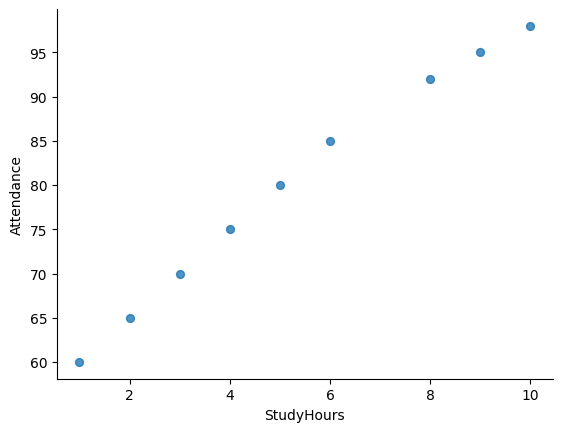

In [40]:
from matplotlib import pyplot as plt
data.plot(kind='scatter', x='StudyHours', y='Attendance', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

In [41]:
# determine input
x = data[["StudyHours","Attendance"]]
y = data['FinalMarks']

In [42]:
#create the pipeline
pipe= Pipeline([
    ("imputer",SimpleImputer(strategy="mean")),      # Fill the missing value with mean  i.e average values
    ("scaler",StandardScaler()),                     # Going to normalize your data
    ("model",LinearRegression())                     # Model of Linear Regression to predict the result
])
pipe

Pipeline(steps=[('imputer', SimpleImputer()), ('scaler', StandardScaler()),
                ('model', LinearRegression())])

In [48]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print("Training set size is",len(x_train))
print("Testing set size is",len(x_test))

Training set size is 8
Testing set size is 2


In [44]:
pipe.fit(x_train,y_train)
y_pred = pipe.predict(x_test)
print("Predicted values are:",y_pred)

Predicted values are: [79.72939068 44.77060932]


In [45]:
mae = mean_absolute_error(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2=r2_score(y_test,y_pred)
#r2 =r2_score(y_test,y_pred)
print("Mean Absolute Error is:",mae)
print("Mean Squared Error is:",mse)
print("Root Mean Squared Error is:",rmse)
print("R-Squared is:",r2)

Mean Absolute Error is: 0.97939068100359
Mean Squared Error is: 1.521706106036681
Root Mean Squared Error is: 1.2335745239087426
R-Squared is: 0.994410629546238


In [46]:
# Predict for a new student
new_student = pd.DataFrame({
    "StudyHours":[6],
    "Attendance":[85]
})
predict_marks=pipe.predict(new_student)
print("Predicted Marks for the new students:",round(predict_marks[0],2))

Predicted Marks for the new students: 65.35


In [47]:
# Predict for a new student
study_hours = int(input("Enter Study Hours for the new student \t"))
attendance = int(input("Enter Attendance for the new student \t"))

new_student = pd.DataFrame({
    "StudyHours":[6],
    "Attendance":[85]
})
predict_marks=pipe.predict(new_student)
print("Predicted Marks for the new students:",round(predict_marks[0],2))

Enter Attendance for the new student 	6
Predicted Marks for the new students: 65.35
